# 03 — Train Field Detector

Train YOLOv11 phát hiện 6 trường trên thẻ CCCD: `id`, `name`, `birth`, `origin`, `address`, `title`.

**Notebook này tự chuẩn bị data nếu chưa có** — có thể chạy độc lập.

**Tiêu chí pass:** mAP@0.5 ≥ 0.75 → chuyển sang module Rectification.

> Sau khi train xong, weights sẽ được tải xuống máy qua `files.download()`.

## 0. Cài đặt

In [1]:
!pip install ultralytics gdown pyyaml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.3 MB/s eta 0:00:00


In [2]:
import json
import shutil
import zipfile
from collections import defaultdict
from pathlib import Path

import cv2
import gdown
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import torch
import yaml
from tqdm.notebook import tqdm
from ultralytics import YOLO

FILE_ID   = "1CzgcY8qbT0HkcBpJdHB5-5rNXvO9kSlZ"

BASE_DIR  = Path("/content")
DATA_YAML = BASE_DIR / "data/yolo/field/data.yaml"
RUNS_DIR  = BASE_DIR / "runs/field_detector"
RUNS_DIR.mkdir(parents=True, exist_ok=True)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 0b. Chuẩn bị data (tự động nếu chưa có)

In [3]:
# 1. Download zip
zip_path = BASE_DIR / "cccd_data.zip"
if not zip_path.exists():
    gdown.download(id=FILE_ID, output=str(zip_path), quiet=False)

# 2. Giai nen
print("Giai nen...")
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(str(BASE_DIR))

# 3. Convert COCO → YOLO
RAW_DIR    = BASE_DIR / "data/cccd.v1i.coco"
SPLITS_DIR = BASE_DIR / "data/processed/splits"
YOLO_DIR   = BASE_DIR / "data/yolo"

# Build bang tra cuu anh
fname_to_path = {}
for split in ["train", "valid", "test"]:
    for p in (RAW_DIR / split).glob("*.jpg"):
        fname_to_path[p.name] = p
print(f"Tim duoc {len(fname_to_path)} anh")

def coco_bbox_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    cx = max(0.0, min(1.0, (x + w / 2) / img_w))
    cy = max(0.0, min(1.0, (y + h / 2) / img_h))
    w  = max(0.0, min(1.0, w / img_w))
    h  = max(0.0, min(1.0, h / img_h))
    return cx, cy, w, h

def convert_split(coco_path, split_name, target_classes, out_dir):
    img_out   = out_dir / "images" / split_name
    label_out = out_dir / "labels" / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    label_out.mkdir(parents=True, exist_ok=True)

    with open(coco_path, encoding="utf-8") as f:
        coco = json.load(f)

    cat_id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
    class_to_idx   = {cls: i for i, cls in enumerate(target_classes)}

    anns_by_img = defaultdict(list)
    for ann in coco["annotations"]:
        if cat_id_to_name.get(ann["category_id"]) in class_to_idx:
            anns_by_img[ann["image_id"]].append(ann)

    for img_info in tqdm(coco["images"], desc=f"  {split_name}", leave=False):
        src = fname_to_path.get(img_info["file_name"])
        if src is None:
            continue
        dst = img_out / img_info["file_name"]
        if not dst.exists():
            shutil.copy2(src, dst)
        lines = []
        for ann in anns_by_img.get(img_info["id"], []):
            cls = cat_id_to_name[ann["category_id"]]
            cx, cy, w, h = coco_bbox_to_yolo(ann["bbox"], img_info["width"], img_info["height"])
            lines.append(f"{class_to_idx[cls]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        (label_out / (Path(img_info["file_name"]).stem + ".txt")).write_text("\n".join(lines))

# Convert field
field_classes = ["id", "name", "birth", "origin", "address", "title"]
field_dir = YOLO_DIR / "field"
print("Convert Field Detector...")
for sn, fn in [("train", "train.json"), ("val", "val.json"), ("test", "test.json")]:
    convert_split(SPLITS_DIR / fn, sn, field_classes, field_dir)

field_yaml = {
    "path": str(field_dir),
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",
    "nc":    len(field_classes),
    "names": field_classes,
}
(field_dir / "data.yaml").write_text(yaml.dump(field_yaml))

Downloading...
From (original): https://drive.google.com/uc?id=1CzgcY8qbT0HkcBpJdHB5-5rNXvO9kSlZ
From (redirected): https://drive.google.com/uc?id=1CzgcY8qbT0HkcBpJdHB5-5rNXvO9kSlZ&confirm=t&uuid=4dd0057f-50af-460f-b3c0-628a7ffb0b6e
To: /content/cccd_data.zip
100%|██████████| 629M/629M [00:06<00:00, 93.0MB/s]


Giai nen...
Tim duoc 4399 anh
Convert Field Detector...


  train:   0%|          | 0/3074 [00:00<?, ?it/s]

  val:   0%|          | 0/699 [00:00<?, ?it/s]

  test:   0%|          | 0/626 [00:00<?, ?it/s]

145

## 1. Cấu hình training

In [4]:
MODEL_SIZE = "yolo11s.pt"  # n=nano, s=small, m=medium
EPOCHS     = 100
IMGSZ      = 640
BATCH      = 16
PATIENCE   = 20
SEED       = 42
MAP_TARGET = 0.75

## 2. Train

In [5]:
model = YOLO(MODEL_SIZE)

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    patience=PATIENCE,
    seed=SEED,
    project=str(RUNS_DIR),
    name="exp",
    exist_ok=True,
    rect=False,
    degrees=10.0,
    translate=0.1,
    scale=0.3,
    perspective=0.0005,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    verbose=True,
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/yolo/field/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspect

## 3. Evaluate trên val set

In [6]:
best_weights = RUNS_DIR / "exp" / "weights" / "best.pt"
model_best   = YOLO(best_weights)

val_results = model_best.val(data=str(DATA_YAML), split="val", imgsz=IMGSZ, verbose=False)
map50 = float(val_results.box.map50)

print("=== Val Results ===")
print(f"  mAP@0.5:    {map50:.4f}")
print(f"  mAP@0.5:95: {val_results.box.map:.4f}")
print(f"  Precision:  {val_results.box.mp:.4f}")
print(f"  Recall:     {val_results.box.mr:.4f}")
print()

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1964.2±521.5 MB/s, size: 59.0 KB)
val: Scanning /content/data/yolo/field/labels/val.cache... 699 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 699/699 209.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 3.7it/s 12.0s
                   all        699       4206      0.999      0.997      0.995      0.849
Speed: 1.6ms preprocess, 10.2ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
=== Val Results ===
  mAP@0.5:    0.9950
  mAP@0.5:95: 0.8488
  Precision:  0.9995
  Recall:     0.9972



## 4. Evaluate trên test set

In [7]:
test_results = model_best.val(data=str(DATA_YAML), split="test", imgsz=IMGSZ, verbose=False)

print(f"  mAP@0.5:    {test_results.box.map50:.4f}")
print(f"  mAP@0.5:95: {test_results.box.map:.4f}")
print(f"  Precision:  {test_results.box.mp:.4f}")
print(f"  Recall:     {test_results.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2391.0±690.3 MB/s, size: 97.1 KB)
val: Scanning /content/data/yolo/field/labels/test... 626 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 626/626 1.9Kit/s 0.3s
val: New cache created: /content/data/yolo/field/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 3.4it/s 11.7s
                   all        626       3790      0.999      0.991      0.993      0.842
Speed: 1.7ms preprocess, 10.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val2
  mAP@0.5:    0.9935
  mAP@0.5:95: 0.8415
  Precision:  0.9993
  Recall:     0.9910


## 5. Kết quả per class

In [8]:
field_classes = ["id", "name", "birth", "origin", "address", "title"]

if val_results.box.ap_class_index is not None:
    for i, cls_idx in enumerate(val_results.box.ap_class_index):
        cls_name = field_classes[cls_idx] if cls_idx < len(field_classes) else str(cls_idx)
        print(f"  {cls_name:10s}: {float(val_results.box.ap50[i]):.4f}")

  id        : 0.9950
  name      : 0.9950
  birth     : 0.9950
  origin    : 0.9950
  address   : 0.9950
  title     : 0.9950


## 6. Visualize training curves

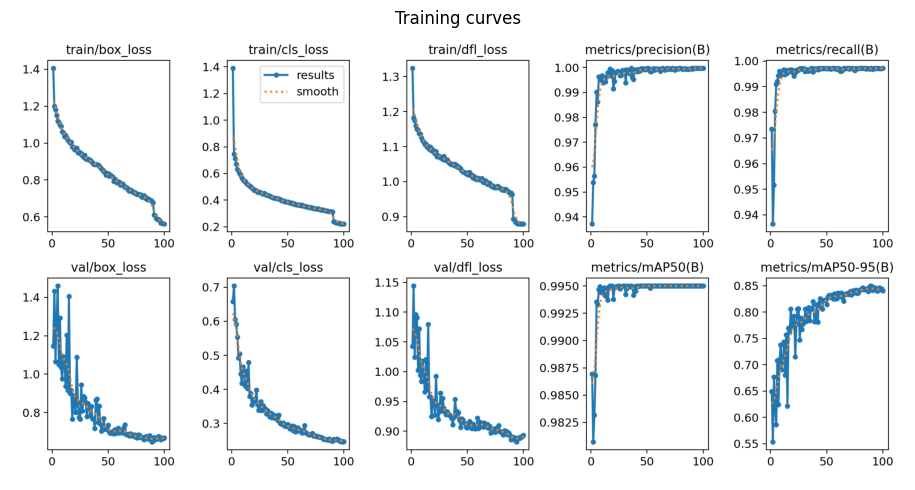

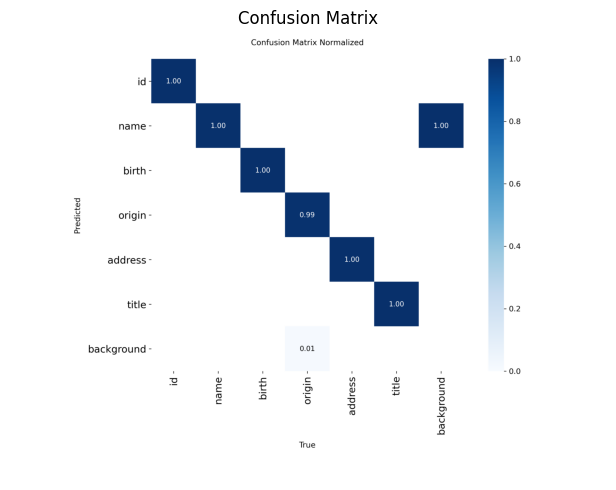

In [9]:
exp_dir = RUNS_DIR / "exp"

for png_name, title in [
    ("results.png", "Training curves"),
    ("confusion_matrix_normalized.png", "Confusion Matrix"),
    ("PR_curve.png", "PR Curve"),
]:
    png = exp_dir / png_name
    if png.exists():
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.imshow(mpimg.imread(png))
        ax.axis("off")
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

## 7. Test thử trên ảnh mẫu

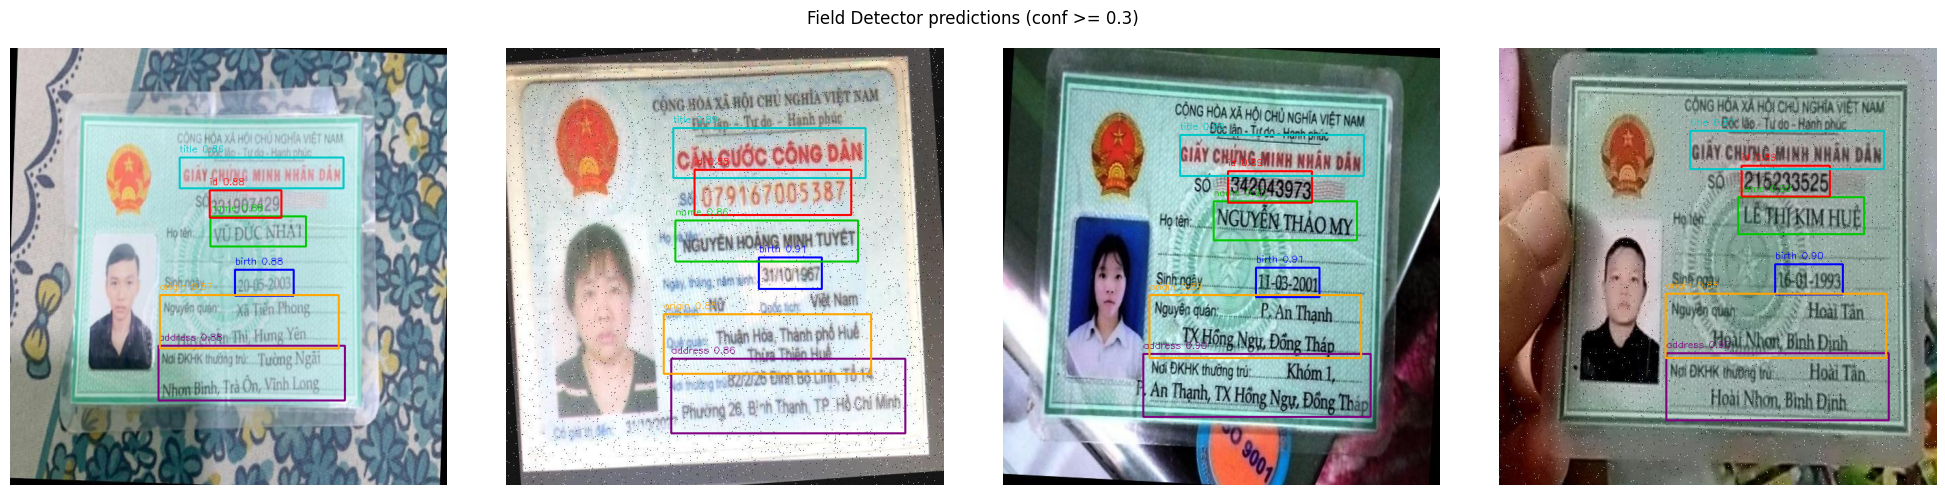

In [10]:
COLORS = {
    "id":      (255, 0,   0),
    "name":    (0,   200, 0),
    "birth":   (0,   0,   255),
    "origin":  (255, 165, 0),
    "address": (128, 0,   128),
    "title":   (0,   200, 200),
}

test_imgs = list(Path("/content/data/yolo/field/images/test").glob("*.jpg"))[:4]

fig, axes = plt.subplots(1, len(test_imgs), figsize=(5 * len(test_imgs), 5))
if len(test_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, test_imgs):
    preds = model_best.predict(img_path, imgsz=IMGSZ, conf=0.3, verbose=False)[0]
    img   = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_idx = int(box.cls[0])
        cls_name = field_classes[cls_idx] if cls_idx < len(field_classes) else str(cls_idx)
        conf  = float(box.conf[0])
        color = COLORS.get(cls_name, (200, 200, 200))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, f"{cls_name} {conf:.2f}", (x1, max(y1 - 8, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Field Detector predictions (conf >= 0.3)")
plt.tight_layout()
plt.show()

## 8. Lưu kết quả & Tải weights về máy

In [11]:
eval_result = {
    "model": MODEL_SIZE,
    "val": {
        "map50":     round(float(val_results.box.map50), 4),
        "map50_95":  round(float(val_results.box.map), 4),
        "precision": round(float(val_results.box.mp), 4),
        "recall":    round(float(val_results.box.mr), 4),
        "pass":      float(val_results.box.map50) >= MAP_TARGET,
    },
    "test": {
        "map50":     round(float(test_results.box.map50), 4),
        "map50_95":  round(float(test_results.box.map), 4),
        "precision": round(float(test_results.box.mp), 4),
        "recall":    round(float(test_results.box.mr), 4),
    },
    "config": {"epochs": EPOCHS, "imgsz": IMGSZ, "batch": BATCH, "seed": SEED},
}

eval_path = exp_dir / "eval_results.json"
with open(eval_path, "w") as f:
    json.dump(eval_result, f, indent=2)

print(json.dumps(eval_result, indent=2))

{
  "model": "yolo11s.pt",
  "val": {
    "map50": 0.995,
    "map50_95": 0.8488,
    "precision": 0.9995,
    "recall": 0.9972,
    "pass": true
  },
  "test": {
    "map50": 0.9935,
    "map50_95": 0.8415,
    "precision": 0.9993,
    "recall": 0.991
  },
  "config": {
    "epochs": 100,
    "imgsz": 640,
    "batch": 16,
    "seed": 42
  }
}


In [13]:
# from google.colab import files

# files.download(str(best_weights))
# files.download(str(eval_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>